# Tree-Based Macroeconomic Regime Classification and Forecaster

Based on:
> Bie, Diebold, He, Li. *Machine Learning and the Yield Curve: Tree-Based Macroeconomic Regime Switching*. (2024).

Classification component:
- Loads and merges macroeconomic data from FRED.
- Computes a rolling 5-year quantile standardization on the data.
- Runs a sequential greedy 2-split tree using Bayesian marginal likelihood as the splitting criterion; Svensson-reconstructed yields are used as target data for the marginal likelihood.
- Labels all months into 3 regimes.
- Visualizes the tree structure and regime statistics.

Forecasting component:
- Implements an expanding-window backtesting framework to predict the macroeconomic regime for the following month ($t+1$).
- Constructs a feature set of lagged regime labels and current NSS parameters ($\beta_0, \beta_1, \beta_2$).
- Trains three machine learning architectures for regime prediction: Logistic Regression, Random Forest, and XGBoost.
- Evaluates and visualizes model performance against "ground truth" labels derived from the full sample classification.

## 0. Imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gammaln
import pandas_datareader as pdr
import os

## 1. Load & Merge Macroeconomic Data

We load the macroeconomic variables mentioned in the paper (Table 5, pg. 17) + the federal funds effective rate using the FRED API.

In [5]:
# User Inputs

os.environ['FRED_API_KEY'] = 'OOPSIES'

'''
Feel free to add/remove any series from this list

From FRED's website:
TB3MS - 3-Month Treasury Bill Secondary Market Rate, Discount Basis
INDPRO - Industrial Production: Total Index
CPIAUCSL - CPI for All Urban Consumers: All Items in U.S. City Average
M2SL - M2 Money Supply
PAYEMS - Total Nonfarm Payroll
UNRATE - Unemployment Rate
WTISPLC - Spot Crude Oil Price: West Texas Intermediate (WTI)
T10Y2YM - 10-Year Treasury Constant Maturity Minus 2-Year Treasury Constant Maturity (Term Spread)
BAMLH0A0HYM2 - ICE BofA US High Yield Index Option-Adjusted Spread (Credit Spread) ONLY STARTS FROM 2023 NOW
VIXCLS - CBOE Volatility Index: VIX
FEDFUNDS - Federal Funds Effective Rate
'''

series = ['TB3MS', 'INDPRO', 'CPIAUCSL', 'M2SL', 'PAYEMS', 'UNRATE', 'WTISPLC', 'T10Y2YM', 'BAMLH0A0HYM2', 'VIXCLS', 'FEDFUNDS']

# Data start and end dates
start_date = '1996-01-01'
end_date = '2100-01-01' # you can change this

# Rolling quantile standardization parameters
rolling_window = 60 # 10-year = 120 months rolling window (pg. 17), we use 5 years to preserve more data

# Tree classification parameters
thresholds = [0.2, 0.4, 0.6, 0.8] # candidate split thresholds (pg. 17)
min_regime_months = 24 # (pg. 11)
max_regimes = 3 # (pg. 11)

In [6]:
# Gets data from FRED API
print('Fetching FRED data...')
raw = pdr.get_data_fred(series, start=start_date, end=end_date)
raw.index = pd.to_datetime(raw.index)
raw = raw.sort_index()
raw = raw.resample('MS').mean()

# Include BAMLH0A0HYM2 data from Internet Archive
df_BAMLH0A0HYM2 = pd.read_csv('BAMLH0A0HYM2.csv', index_col='observation_date', parse_dates=True)
df_BAMLH0A0HYM2 = df_BAMLH0A0HYM2.ffill()
df_BAMLH0A0HYM2 = df_BAMLH0A0HYM2.resample('MS').mean()
df_BAMLH0A0HYM2 = df_BAMLH0A0HYM2.combine_first(raw[['BAMLH0A0HYM2']])
raw['BAMLH0A0HYM2'] = df_BAMLH0A0HYM2['BAMLH0A0HYM2']

# Check data
print(f'\nAmount of data:')
for col in raw.columns:
    print(f'{col:20s} | {f'{raw[col].notna().sum()} months':20s} | '
          f'{raw[col].first_valid_index().date()} → {raw[col].last_valid_index().date()}')

print(f'\nMissing values per column:')
print(raw.isnull().sum())

print(f'\nMerged shape: {raw.shape}')

Fetching FRED data...

Amount of data:
TB3MS                | 363 months           | 1996-01-01 → 2026-03-01
INDPRO               | 363 months           | 1996-01-01 → 2026-03-01
CPIAUCSL             | 362 months           | 1996-01-01 → 2026-03-01
M2SL                 | 362 months           | 1996-01-01 → 2026-02-01
PAYEMS               | 363 months           | 1996-01-01 → 2026-03-01
UNRATE               | 362 months           | 1996-01-01 → 2026-03-01
WTISPLC              | 363 months           | 1996-01-01 → 2026-03-01
T10Y2YM              | 363 months           | 1996-01-01 → 2026-03-01
BAMLH0A0HYM2         | 353 months           | 1996-12-01 → 2026-04-01
VIXCLS               | 364 months           | 1996-01-01 → 2026-04-01
FEDFUNDS             | 363 months           | 1996-01-01 → 2026-03-01

Missing values per column:
TB3MS            1
INDPRO           1
CPIAUCSL         2
M2SL             2
PAYEMS           1
UNRATE           2
WTISPLC          1
T10Y2YM          1
BAMLH0A0HYM

Final date range: 1996-12-01 → 2026-04-01
Total months: 353

Missing values per column:
TB3MS           0
INDPRO          0
CPIAUCSL        0
M2SL            0
PAYEMS          0
UNRATE          0
WTISPLC         0
T10Y2YM         0
BAMLH0A0HYM2    0
VIXCLS          0
FEDFUNDS        0
dtype: int64
            TB3MS   INDPRO  CPIAUCSL    M2SL    PAYEMS  UNRATE  WTISPLC  \
DATE                                                                      
1996-12-01   4.91  77.5333     159.1  3818.6  121143.0     5.4    25.39   
1997-01-01   5.03  77.6562     159.4  3834.6  121356.0     5.3    25.17   
1997-02-01   5.01  78.5833     159.7  3846.3  121673.0     5.2    22.21   
1997-03-01   5.14  79.0820     159.8  3861.2  121991.0     5.2    20.99   
1997-04-01   5.16  79.1747     159.9  3877.0  122289.0     5.1    19.72   

            T10Y2YM  BAMLH0A0HYM2     VIXCLS  FEDFUNDS  
DATE                                                    
1996-12-01     0.52      3.130000  19.260952      5.29  
1997

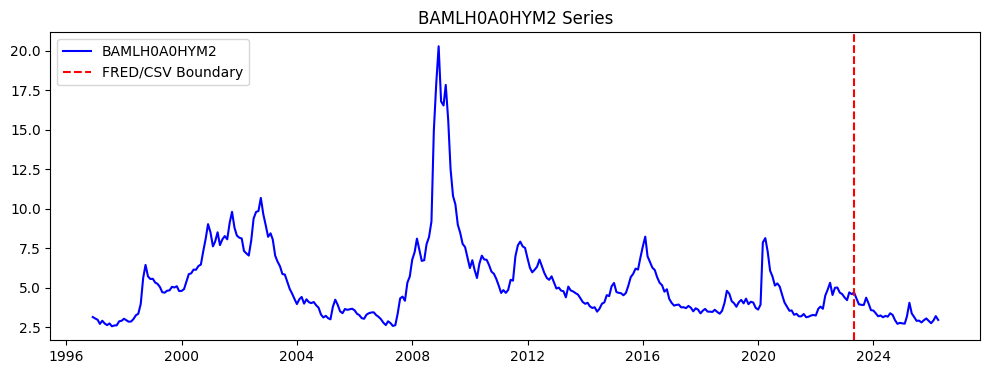

In [7]:
# Clean data
data = raw.loc[start_date:end_date].copy()
data = data.ffill().dropna()

# Check data again
print(f'Final date range: {data.index.min().date()} → {data.index.max().date()}')
print(f'Total months: {len(data)}')

print(f'\nMissing values per column:')
print(data.isnull().sum())

# Preview the data
print(data.head())

# Check BAMLH0A0HYM2 data
plt.figure(figsize=(12, 4))
plt.plot(data.index, data['BAMLH0A0HYM2'], label='BAMLH0A0HYM2', color='blue')
plt.title('BAMLH0A0HYM2 Series')
plt.axvline(pd.Timestamp('2023-04-25'), color='red', linestyle='--', label='FRED/CSV Boundary')
plt.legend()
plt.show()

In [8]:
# Map FRED variable names (keys) to the paper's variable names (values)
# Keys = your column name, Values = short label used in the rest of the notebook.

macro_map = {
    'TB3MS': 'DTB3',
    'INDPRO': 'INDPRO',
    'CPIAUCSL': 'CPI',
    'M2SL': 'M2',
    'PAYEMS': 'PAYEMS',
    'UNRATE': 'UNRATE',
    'WTISPLC': 'OILPRICE',
    'T10Y2YM': 'TERM_SPREAD',
    # 'BAMLH0A0HYM2': 'CREDIT_SPREAD',
    'VIXCLS': 'VIX',
    'FEDFUNDS': 'FFR'
}

# Rename columns
data = data.rename(columns=macro_map)
macro_cols = list(macro_map.values())

## 2. Compute Year-over-Year Changes
For level series (CPI, industrial production, M2, payrolls, oil price),
we compute YoY percent change as the paper does.
Rate/spread/index series (FFR, UNRATE, T-bill, VIX, term spread, default spread)
are used as-is or as levels.

In [9]:
# Series that need YoY % change transformation (Table 5, pg. 17)
YoY_cols = ['INDPRO', 'CPI', 'M2', 'PAYEMS', 'OILPRICE']

# Apply YoY transformation where needed
for col in YoY_cols:
    if col in data.columns:
        data[col] = data[col].pct_change(12) * 100
        print(f'Applied YoY % change to: {col}')

# Drop NaNs introduced by the YoY transformation
data = data.ffill().dropna()

# Check data
print(f'\nFinal shape after YoY transforms: {data.shape}')
data[macro_cols].describe().round(2)

Applied YoY % change to: INDPRO
Applied YoY % change to: CPI
Applied YoY % change to: M2
Applied YoY % change to: PAYEMS
Applied YoY % change to: OILPRICE

Final shape after YoY transforms: (341, 11)


,DTB3,INDPRO,CPI,M2,PAYEMS,UNRATE,OILPRICE,TERM_SPREAD,VIX,FFR
count,341.00,341.00,341.00,341.00,341.00,341.00,341.00,341.00,341.00,341.00
mean,2.12,0.93,2.53,6.41,0.94,5.53,10.99,0.99,20.23,2.26
std,2.00,4.28,1.67,4.42,2.45,1.89,40.46,0.96,7.85,2.12
min,0.01,-17.32,-1.96,-4.63,-13.39,3.40,-74.08,-0.93,10.13,0.05
25%,0.13,-0.74,1.62,4.48,0.40,4.20,-15.41,0.18,14.45,0.16
50%,1.58,1.86,2.29,6.10,1.53,4.90,6.60,0.86,18.89,1.69
75%,4.23,3.21,3.19,7.41,1.92,6.10,33.55,1.80,23.87,4.48
max,6.17,16.55,8.98,26.78,10.86,14.80,272.93,2.83,62.67,6.54


## 3. Rolling 5-Year Quantile Standardization
As in the paper, we replace each macro value with its quantile rank within the past 60 months.

In [10]:
def rolling_quantile_standardize(series, window=120):
    """
    For each time t, compute the quantile rank of series[t]
    within the past 'window' observations.
    """
    result = pd.Series(index=series.index, dtype=float)
    for i in range(window-1, len(series)):
        window_data = series.iloc[i-(window-1):i+1].dropna()
        result.iloc[i] = (window_data <= series.iloc[i]).sum() / len(window_data)

    return result

print('Computing rolling quantile standardization...')
data_q = pd.DataFrame(index=data.index)

for col in macro_cols:
    data_q[col] = rolling_quantile_standardize(data[col], window=rolling_window)

# Clean quantile data
data_q = data_q.ffill().dropna()

# Check quantile data
print(f'\nStandardized shape: {data_q.shape}')
data_q.describe().round(2)

Computing rolling quantile standardization...

Standardized shape: (282, 10)


,DTB3,INDPRO,CPI,M2,PAYEMS,UNRATE,OILPRICE,TERM_SPREAD,VIX,FFR
count,282.00,282.00,282.00,282.00,282.00,282.00,282.00,282.00,282.00,282.00
mean,0.51,0.49,0.53,0.45,0.50,0.42,0.50,0.42,0.44,0.54
std,0.37,0.28,0.30,0.32,0.34,0.35,0.29,0.34,0.33,0.37
min,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02,0.02
25%,0.15,0.33,0.29,0.15,0.17,0.07,0.25,0.10,0.10,0.17
50%,0.42,0.48,0.50,0.43,0.49,0.37,0.50,0.37,0.38,0.55
75%,0.95,0.70,0.81,0.72,0.85,0.75,0.73,0.73,0.76,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


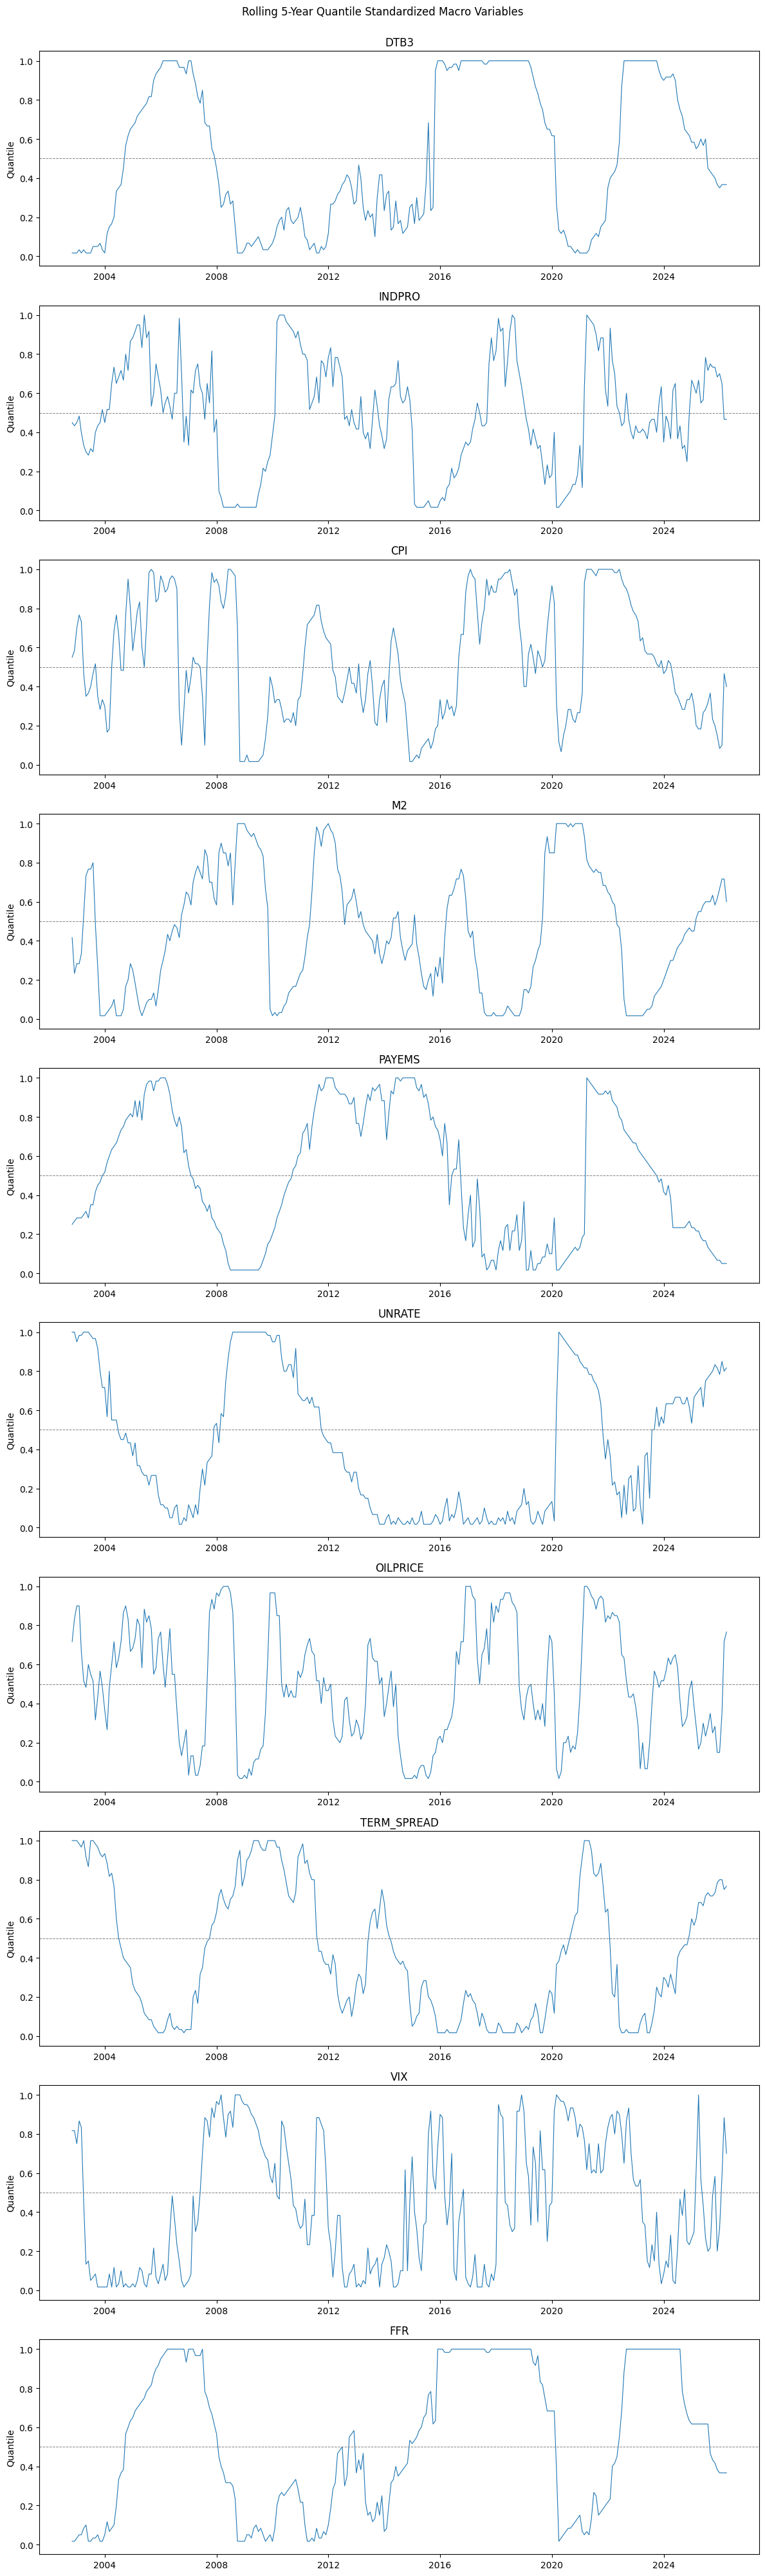

In [11]:
# Plot standardized macro variables
n_cols = len(macro_cols)
fig, axes = plt.subplots(n_cols, 1, figsize=(12, 4*n_cols))

for i, col in enumerate(macro_cols):
    axes[i].plot(data_q.index, data_q[col], lw=0.8)
    axes[i].axhline(0.5, color='gray', lw=0.7, linestyle='--')
    axes[i].set_title(col)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].set_ylabel('Quantile')

plt.suptitle('Rolling 5-Year Quantile Standardized Macro Variables', y=1.0)
plt.tight_layout()
plt.show()

## 4. Bayesian Marginal Likelihood (Splitting Criterion)

Instead of splitting based on the marginal likelihood of a DNS model, as in the paper, we compute the Bayesian marginal likelihood under a Normal-Inverse-Gamma conjugate model:

$$p(Y) = \int p(Y | \mu, \sigma^2) \, p(\mu, \sigma^2) \, d\mu \, d\sigma^2$$

This has a closed-form expression (see below). It naturally penalizes splits that reduce regime size
without improving fit.

**Model:**
* Likelihood - $Y_i \sim \mathcal{N}(\mu, \sigma^2)$: $Y_i$ is a single observation (e.g., the CPI quantile for June 2024). We assume that within any specific economic regime, the macro variable follows a Normal distribution with some mean ($\mu$) and variance ($\sigma^2$).
* Prior for the Mean - $\mu \sim \mathcal{N}(\mu_0, \sigma^2 / \kappa_0)$: Since we don't know the "true" average of the regime, we treat $\mu$ as a random variable. We assume it's centered at our best guess $\mu_0$. The variance is scaled by $\sigma^2$ because if the data is generally very noisy, our guess for the mean should be noisier too.
* Prior for the Variance - $\sigma^2 \sim \text{IG}(\alpha_0, \beta_0)$: The Inverse-Gamma (IG) is the standard distribution for "variance" because it is only defined for positive numbers and has a "fat tail," which accounts for the possibility of sudden high-volatility regimes.

**Prior Hyperparameters:**
* Mean - $\mu_0$
* Precision Scaling - $\kappa_0$
* Shape for Inverse Gamma - $\alpha_0$
* Scale for Inverse Gamma - $\beta_0$

**Posterior Hyperparameters (from Wikipedia, unfortunately):**
* Sample Mean: $$\overline{y} = \frac{1}{n}\sum_{i=1}^n Y_i$$
* Mean (weighted average of prior and data): $$\mu_n = \frac{\kappa_0 \mu_0 + n \overline{y}}{\kappa_0 + n}$$
* Precision Scaling: $$\kappa_n = \kappa_0 + n$$
* Shape for Inverse Gamma: $$\alpha_n = \alpha_0 + \frac{n}{2}$$
* Scale for Inverse Gamma: $$\beta_n = \beta_0 + \frac{1}{2} \sum_{i=1}^n (Y_i - \overline{y})^2 + \frac{n \kappa_0}{\kappa_0 + n} \frac{(\mu_0 - \overline{y})^2}{2}$$

**Marginal Likelihood:** $$p(Y) = \frac{1}{(2\pi)^{n/2}} \sqrt{\frac{\kappa_0}{\kappa_n}} \frac{\Gamma(\alpha_n)}{\Gamma(\alpha_0)} \frac{\beta_0^{\alpha_0}}{\beta_n^{\alpha_n}}$$

In [12]:
# Log marginal likelihood under a Normal-Inverse-Gamma (NIG) conjugate model
def log_marginal_likelihood_nig(Y, mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0):
    # Clean array
    Y = np.asarray(Y, dtype=float)
    Y = Y[np.isfinite(Y)]
    n = len(Y)
    if n < 2: # We need at least 2 points to define a variance
        return -np.inf # -inf ensures the tree rejects splits that create singleton regimes

    # Posterior hyperparameters
    ybar = Y.mean()
    kappa_n = kappa0 + n
    mu_n = (kappa0 * mu0 + n * ybar) / kappa_n
    alpha_n = alpha0 + n / 2.0
    beta_n = (beta0 + np.sum((Y - ybar) ** 2) / 2.0 + (n * kappa0 * (ybar - mu0) ** 2) / (2.0 * kappa_n))

    # Log marginal likelihood
    log_ml = - (n / 2.0) * np.log(2.0 * np.pi) + (1 / 2.0) * np.log(kappa0 / kappa_n) + (gammaln(alpha_n) - gammaln(alpha0)) + alpha0 * np.log(beta0) - alpha_n * np.log(beta_n)

    return log_ml

# Sum of log marginal likelihoods across all regimes
def total_log_ml(regime_labels, target_data, unique_labels=None):
    # Monthly regime labels
    regime_labels = np.asarray(regime_labels)
    if unique_labels is None:
        unique_labels = np.unique(regime_labels)

    # Yields or macro data
    target = np.asarray(target_data)
    if target.ndim == 1:
        target = target.reshape(target.shape, 1)

    # Compute sum
    total = 0.0
    for label in unique_labels:
        mask = (regime_labels == label)

        # Insufficient data
        if mask.sum() < 2:
            return -np.inf

        for col_idx in range(target.shape[1]):
            total += log_marginal_likelihood_nig(target[mask, col_idx])

    return total

print('Bayesian marginal likelihood functions defined.')

Bayesian marginal likelihood functions defined.


## 5. Reconstruct Yields from Nelson-Siegel-Svensson (NSS) Parameters
We load the Fed's NSS parameters (`feds200628.csv`) and reconstruct zero-coupon yields at 13 maturities (pg. 12). These reconstructed yields are used as the marginal likelihood target in both the full-sample classifier and the expanding
window forecaster.

In [13]:
# Load Svensson parameters
svensson_raw = pd.read_csv('feds200628.csv', skiprows=9, index_col=0, parse_dates=True)
svensson_raw = svensson_raw[['BETA0', 'BETA1', 'BETA2', 'BETA3', 'TAU1', 'TAU2']]
svensson_raw = svensson_raw.replace(-999.99, np.nan).dropna()
svensson_monthly = svensson_raw.resample('MS').first().dropna()

# Check data
print(f'Svensson parameters: {svensson_monthly.shape}')
print(f'Date range: {svensson_monthly.index.min().date()} → {svensson_monthly.index.max().date()}')

# Svensson yield reconstruction
def svensson_yield(tau_months, beta0, beta1, beta2, beta3, tau1, tau2):
    tau = tau_months / 12.0  # convert to years
    f1 = (1 - np.exp(-tau / tau1)) / (tau / tau1)
    f2 = f1 - np.exp(-tau / tau1)
    f3 = (1 - np.exp(-tau / tau2)) / (tau / tau2) - np.exp(-tau / tau2)
    return beta0 + beta1 * f1 + beta2 * f2 + beta3 * f3

# Reconstruct at 13 maturities (pg. 12)
maturities_months = [3, 6, 9, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120]
maturity_labels = [f'Y{m}M' for m in maturities_months]

yields_svensson = pd.DataFrame(index=svensson_monthly.index, columns=maturity_labels, dtype=float)

for date, row in svensson_monthly.iterrows():
    for m, label in zip(maturities_months, maturity_labels):
        yields_svensson.loc[date, label] = svensson_yield(m, row.BETA0, row.BETA1, row.BETA2, row.BETA3, row.TAU1, row.TAU2)

# Clean data
yields_svensson = yields_svensson.dropna()

# Check data
print(f'\nReconstructed yields shape: {yields_svensson.shape}')
print(f'Date range: {yields_svensson.index.min().date()} → {yields_svensson.index.max().date()}')
yields_svensson.head()

Svensson parameters: (556, 6)
Date range: 1980-01-01 → 2026-04-01

Reconstructed yields shape: (556, 13)
Date range: 1980-01-01 → 2026-04-01


,Y3M,Y6M,Y9M,Y12M,Y24M,Y36M,Y48M,Y60M,Y72M,Y84M,Y96M,Y108M,Y120M
Date,,,,,,,,,,,,,
1980-01-01,12.578174,12.204127,11.881552,11.603698,10.832514,10.421302,10.211237,10.111768,10.071732,10.062548,10.068496,10.081114,10.095983
1980-02-01,12.460933,12.250100,12.060350,11.890033,11.373421,11.059761,10.885231,10.803453,10.781598,10.796959,10.834169,10.883059,10.937075
1980-03-01,14.275042,14.578194,14.692831,14.680344,14.080893,13.382222,12.881085,12.566536,12.376847,12.261603,12.188848,12.140210,12.105566
1980-04-01,15.693937,15.509740,15.274143,15.008758,13.911927,13.041023,12.473271,12.149926,11.992111,11.935610,11.936218,11.966170,12.009126
1980-05-01,10.970851,10.793823,10.642654,10.514198,10.176408,10.029190,9.990632,10.011446,10.062393,10.126469,10.194073,10.260035,10.321791


## 6. Target Variable Setup
We use the Svensson-reconstructed yields as target data for the marginal likelihood.

Although using reconstructed yields results in a significantly lower log marginal likelihood compared to using raw yields, the signal-to-noise ratio is arguably higher. This is because the NSS model acts as a structural filter, smoothing out market noise. Additionally, raw yields have more degrees of freedom, which allows for more flexibility in fitting and thus an artificially lower log marginal likelihood.

In [14]:
# Align Svensson yields and macro quantiles to a common date index
common_idx = data_q.index.intersection(yields_svensson.index).sort_values()
data_q = data_q.loc[common_idx]
target_data = yields_svensson.loc[common_idx].values

'''
Alternative Target Options

# Yields as Target
common_idx = data_q.index # align everything to common dates
yield_series = ['DGS3MO', 'DGS1', 'DGS2', 'DGS5', 'DGS10', 'DGS30']
yields = pdr.get_data_fred(yield_series, start=start_date, end=end_date)
yields = yields.resample('MS').mean()
yields.columns = ['Y3M', 'Y1Y', 'Y2Y', 'Y5Y', 'Y10Y', 'Y30Y']
yields = yields.ffill().dropna()
yields = yields.loc[data_q.index]
target_data = yields.values

# Macros as Target Data
common_idx = data_q.index # align everything to common dates
target_data = data.loc[common_idx, macro_cols].values # raw macro values
'''

# Check data
print(f'Target data shape: {target_data.shape}')
print(f'Macro (split candidates) shape: {data_q.shape}')
print(f'Date range: {common_idx.min().date()} → {common_idx.max().date()}')

Target data shape: (282, 13)
Macro (split candidates) shape: (282, 10)
Date range: 2002-11-01 → 2026-04-01


## 7. Sequential Tree Growing (2 Splits, 3 Regimes)
Greedy search: at each step, we evaluate every candidate
(macro variable $\times$ threshold) on every current leaf node and
pick the one with the highest total marginal likelihood (sec. 2.2.2).

In [15]:
# Search all (variable, threshold) combinations for the best split of a given leaf node
def find_best_split(regime_labels, leaf_label, data_q, target_data, thresholds, min_obs, next_label):
    """
    Parameters:
    regime_labels - regime label array for all observations
    leaf_label - integer label of the leaf node to split
    data_q - DataFrame of standardized macro variables (split candidates)
    target_data - array of target observations (yields or macros)
    thresholds - list of quantile thresholds to try
    min_obs - minimum observations required in each resulting regime
    next_label - integer label to assign to the new (right) child node

    Returns:
    best_macro - column name of the best splitting variable
    best_threshold - quantile threshold of the best split
    best_ml - total log marginal likelihood achieved
    best_labels - updated regime label array after the split
    """
    leaf_mask = (regime_labels == leaf_label)

    # Initialize best guesses
    best_ml = -np.inf
    best_macro = None
    best_threshold = None
    best_labels = None

    # Track all results for diagnostics
    all_results = []

    for macro in data_q.columns:
        for threshold in thresholds:
            # Proposed split: where var < threshold -> leaf_label; where var >= threshold -> next_label
            candidate_labels = regime_labels.copy()
            split_mask = leaf_mask & (data_q[macro].values >= threshold)
            candidate_labels[split_mask] = next_label

            # Check minimum number of observations in both new child nodes
            left_count  = (leaf_mask & (data_q[macro].values < threshold)).sum()
            right_count = (leaf_mask & (data_q[macro].values >= threshold)).sum()
            if left_count < min_obs or right_count < min_obs:
                continue

            # Evaluate total marginal likelihood across all regimes
            ml = total_log_ml(candidate_labels, target_data)

            # Append results
            all_results.append({'macro': macro, 'threshold': threshold, 'ml': ml})

            if ml > best_ml:
                best_ml = ml
                best_macro = macro
                best_threshold = threshold
                best_labels = candidate_labels.copy()

    # Print top 5 candidates
    all_results = sorted(all_results, key=lambda x: x['ml'], reverse=True)
    print(f'\n  Top 5 candidates for Leaf {leaf_label}:')
    for r in all_results[:5]:
        print(f'    {r["macro"]:20s} threshold = {r["threshold"]} | log ML = {r["ml"]:.4f}')

    return best_macro, best_threshold, best_ml, best_labels

print('Split search function defined.')

Split search function defined.


In [16]:
# Grow tree
def grow_tree(data_q, target_data, thresholds, min_obs, max_regimes):
    """
    At each step:
      1. Try splitting every current leaf
      2. Pick the (leaf, variable, threshold) combination with highest total marginal likelihood
      3. Apply the split and record it
      4. Stop when max_regimes is reached
    """
    n = len(data_q) # total number of observations (months)
    regime_labels = np.zeros(n, dtype=int) # start every observation in regime 0
    splits = [] # empty list to record split decisions
    n_regimes = 1 # start with 1 regime
    next_label = 1 # the label to assign to the next new regime

    while n_regimes < max_regimes:
        print(f'\n── Split {len(splits)+1}: Searching across '
              f'{n_regimes} leaf node(s) × '
              f'{len(data_q.columns)} variables × '
              f'{len(thresholds)} thresholds ──')

        best_global_ml = -np.inf
        best_global_macro = None
        best_global_threshold = None
        best_global_labels = None
        best_leaf = None

        current_leaves = np.unique(regime_labels)

        for leaf in current_leaves:
            leaf_size = (regime_labels == leaf).sum()
            if leaf_size < 2 * min_obs:
                print(f'\nLeaf {leaf}: too small to split ({leaf_size} observations), skipping.')
                continue

            macro, threshold, ml, labels = find_best_split(regime_labels, leaf, data_q, target_data, thresholds, min_obs, next_label)

            if macro is not None:
                if ml > best_global_ml:
                    best_global_ml = ml
                    best_global_macro = macro
                    best_global_threshold = threshold
                    best_global_labels = labels
                    best_leaf = leaf
            else:
                print(f'Leaf {leaf}: no valid split found.')

        if best_global_macro is None:
            print('No valid split found anywhere. Stopping.')
            break

        # Apply the best split
        regime_labels = best_global_labels
        split_info = {
            'number_of_splits': len(splits) + 1,
            'leaf_split': best_leaf,
            'macro_variable': best_global_macro,
            'threshold': best_global_threshold,
            'log_ml': best_global_ml,
            'new_label': next_label
        }
        splits.append(split_info)

        print(f'\nSplit {len(splits)} applied: '
              f'  Leaf {best_leaf} split on {best_global_macro} at {best_global_threshold:.1f}')

        for label in np.unique(regime_labels):
            count = (regime_labels == label).sum()
            print(f'    Regime {label}: {count} months')

        next_label += 1
        n_regimes  += 1

    return regime_labels, splits

print('Tree growing function defined.')

Tree growing function defined.


In [17]:
print('Growing macro-instrumented regime tree...')

regime_labels, splits = grow_tree(
    data_q = data_q,
    target_data = target_data,
    thresholds = thresholds,
    min_obs = min_regime_months,
    max_regimes = max_regimes
)

print('\nTree growing complete.')

Growing macro-instrumented regime tree...

── Split 1: Searching across 1 leaf node(s) × 10 variables × 4 thresholds ──

  Top 5 candidates for Leaf 0:
    DTB3                 threshold = 0.4 | log ML = -5876.9753
    FFR                  threshold = 0.6 | log ML = -5959.8620
    DTB3                 threshold = 0.2 | log ML = -5987.8238
    FFR                  threshold = 0.4 | log ML = -6079.8283
    DTB3                 threshold = 0.6 | log ML = -6109.8780

Split 1 applied:   Leaf 0 split on DTB3 at 0.4
    Regime 0: 136 months
    Regime 1: 146 months

── Split 2: Searching across 2 leaf node(s) × 10 variables × 4 thresholds ──

  Top 5 candidates for Leaf 0:
    PAYEMS               threshold = 0.8 | log ML = -5326.6950
    UNRATE               threshold = 0.4 | log ML = -5544.5795
    TERM_SPREAD          threshold = 0.6 | log ML = -5605.8589
    TERM_SPREAD          threshold = 0.4 | log ML = -5632.6205
    PAYEMS               threshold = 0.6 | log ML = -5655.6033

  Top 5 c

## 8. Results, Tree Structure, and Regime Summary

In [18]:
print('Tree Structure')

for s in splits:
    print(f"\nSplit {s['number_of_splits']}:")
    print(f"  Node split    : Regime {s['leaf_split']}")
    print(f"  Macro Variable: {s['macro_variable']}")
    print(f"  Threshold     : {s['threshold']}")
    print(f"  Log ML        : {s['log_ml']:.4f}")
    print(f"  Left child    : Regime {s['leaf_split']}  "
          f"({s['macro_variable']} < {s['threshold']})")
    print(f"  Right child   : Regime {s['new_label']}  "
          f"({s['macro_variable']} >= {s['threshold']})")
    print()

print('────────────────────────────────────────────')
print('Regime Sizes:')
for label in sorted(np.unique(regime_labels)):
    count = (regime_labels == label).sum()
    pct = count / len(regime_labels) * 100
    print(f'  Regime {label}: {count:4d} months  ({pct:.1f}%)')

Tree Structure

Split 1:
  Node split    : Regime 0
  Macro Variable: DTB3
  Threshold     : 0.4
  Log ML        : -5876.9753
  Left child    : Regime 0  (DTB3 < 0.4)
  Right child   : Regime 1  (DTB3 >= 0.4)


Split 2:
  Node split    : Regime 0
  Macro Variable: PAYEMS
  Threshold     : 0.8
  Log ML        : -5326.6950
  Left child    : Regime 0  (PAYEMS < 0.8)
  Right child   : Regime 2  (PAYEMS >= 0.8)

────────────────────────────────────────────
Regime Sizes:
  Regime 0:   85 months  (30.1%)
  Regime 1:  146 months  (51.8%)
  Regime 2:   51 months  (18.1%)


## 9. Visualizations

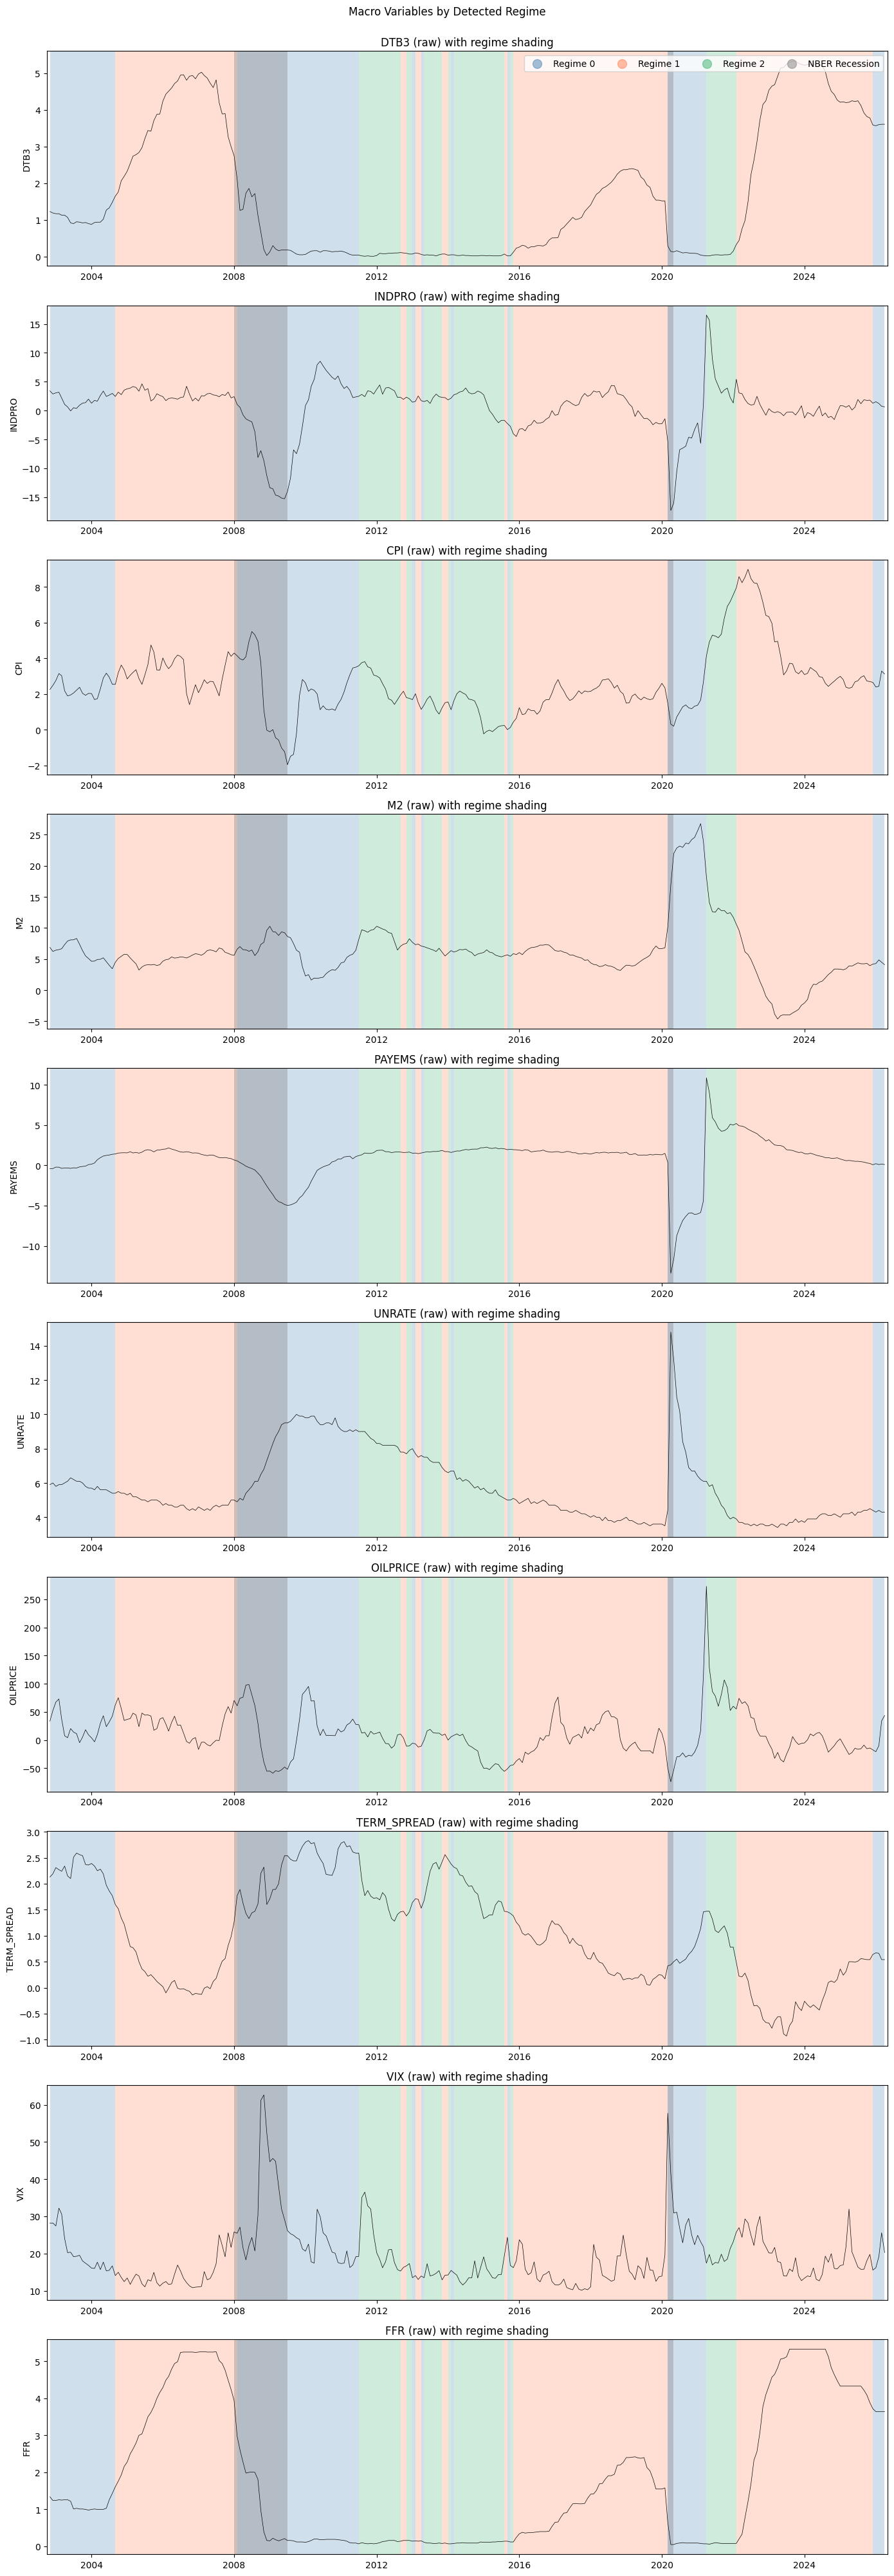

In [19]:
# Get NBER recession dates from FRED
recession = pdr.get_data_fred('USREC', start=start_date, end=end_date)
recession = recession.ffill().fillna(0)

# Plots of Macro Variables Colored by Regime
n_cols_plot = len(macro_cols)
fig, axes = plt.subplots(n_cols_plot, 1, figsize=(14, 4 * n_cols_plot))
colors = {0: 'steelblue', 1: 'coral', 2: 'mediumseagreen', 3: 'orchid', 4: 'goldenrod'}

if n_cols_plot == 1:
    axes = [axes]

for ax, col in zip(axes, macro_cols):
    ax.plot(common_idx, data.loc[common_idx, col], color='black', lw=0.5, zorder=2)

    # Shade background by regime
    for label in np.unique(regime_labels):
        mask = (regime_labels == label)
        regime_dates = common_idx[mask]

        # Find contiguous blocks
        in_block = False
        block_start = None
        for i, date in enumerate(common_idx):
            if mask[i] and not in_block:
                in_block = True
                block_start = date
            # If this month does not belong to the current regime and we were in a block, the block just ended
            elif not mask[i] and in_block:
                in_block = False
                ax.axvspan(block_start, date, alpha=0.25, color=colors[label], lw=0) # Draw the span from `block_start` to `date`
        # Close any open block at the end of the sample
        if in_block:
            ax.axvspan(block_start, common_idx[-1], alpha=0.25, color=colors[label], lw=0)

    # Shade NBER recessions
    in_recession = False
    rec_start = None
    for date, val in recession.iterrows():
        if val['USREC'] == 1 and not in_recession:
            in_recession = True
            rec_start = date
        elif val['USREC'] == 0 and in_recession:
            in_recession = False
            ax.axvspan(rec_start, date, alpha=0.35, color='grey', lw=0, zorder=1)
    # Close any open recession at end of sample
    if in_recession:
        ax.axvspan(rec_start, recession.index[-1], alpha=0.25, color='grey', lw=0, zorder=1)

    ax.set_xlim(common_idx.min() - pd.DateOffset(months=1), common_idx.max() + pd.DateOffset(months=1))
    ax.set_ylabel(col)
    ax.set_title(f'{col} (raw) with regime shading')

# Legend
for label in np.unique(regime_labels):
    axes[0].scatter([], [], color=colors[label], alpha=0.5, label=f'Regime {label}', s=100)
axes[0].scatter([], [], color='grey', alpha=0.5, label='NBER Recession', s=100)
axes[0].legend(loc='upper right', ncol=len(np.unique(regime_labels)) + 1)

plt.suptitle('Macro Variables by Detected Regime', y=1.0)
plt.tight_layout()
plt.show()

## 10. Data Analysis and Statistics

In [20]:
# Record everything in one table
results = pd.DataFrame(index=common_idx)
results[macro_cols] = data.loc[common_idx, macro_cols] # raw values
results[[f'{col}_q' for col in macro_cols]] = data_q.loc[common_idx] # quantile values
results['regime'] = regime_labels

# Preview
results.head()

,DTB3,INDPRO,CPI,M2,PAYEMS,UNRATE,OILPRICE,TERM_SPREAD,VIX,FFR,...,INDPRO_q,CPI_q,M2_q,PAYEMS_q,UNRATE_q,OILPRICE_q,TERM_SPREAD_q,VIX_q,FFR_q,regime
2002-11-01,1.23,3.411504,2.253521,6.878886,-0.402611,5.9,33.553635,2.13,28.175000,1.34,...,0.450000,0.550000,0.416667,0.250000,1.000000,0.716667,1.000000,0.816667,0.016667,0
2002-12-01,1.19,2.880394,2.480271,6.229207,-0.395471,6.0,52.198655,2.19,28.210476,1.24,...,0.433333,0.583333,0.233333,0.266667,1.000000,0.833333,1.000000,0.816667,0.016667,0
2003-01-01,1.17,3.071141,2.757456,6.431174,-0.218556,5.8,67.463142,2.31,27.424286,1.24,...,0.450000,0.700000,0.283333,0.283333,0.950000,0.900000,1.000000,0.750000,0.033333,0
2003-02-01,1.17,3.181712,3.146067,6.520710,-0.226409,5.9,72.950820,2.27,32.218421,1.26,...,0.483333,0.766667,0.283333,0.283333,0.983333,0.900000,0.983333,0.866667,0.050000,0
2003-03-01,1.13,2.170944,3.025210,6.659397,-0.372546,5.9,37.387387,2.24,30.634286,1.25,...,0.400000,0.733333,0.333333,0.283333,0.983333,0.666667,0.966667,0.833333,0.050000,0


In [21]:
# Recession Overlap Statistics
print('Recession Overlap Statistics:')

recession = recession.reindex(common_idx, method='ffill').fillna(0)
rec_mask = recession['USREC'].values == 1
total_rec_months = rec_mask.sum()
total_months = len(common_idx)

print(f'\n  Total months in sample: {total_months}')
print(f'  Total recession months: {total_rec_months} ({total_rec_months/total_months*100:.1f}%)')

for label in sorted(np.unique(regime_labels)):
    regime_mask = (regime_labels == label)
    regime_months = regime_mask.sum()

    # Months that are both in this regime AND in recession
    overlap = (regime_mask & rec_mask).sum()

    # % of this regime that is recession
    pct_of_regime = overlap / regime_months * 100

    # % of all recessions captured by this regime
    pct_of_rec = overlap / total_rec_months * 100

    print(f'\nRegime {label} ({regime_months:3d} months):')
    print(f'  Recession months: {overlap}')
    print(f'  % of regime in recession: {pct_of_regime:.1f}%')
    print(f'  % of recessions captured: {pct_of_rec:.1f}%')

Recession Overlap Statistics:

  Total months in sample: 282
  Total recession months: 20 (7.1%)

Regime 0 ( 85 months):
  Recession months: 19
  % of regime in recession: 22.4%
  % of recessions captured: 95.0%

Regime 1 (146 months):
  Recession months: 1
  % of regime in recession: 0.7%
  % of recessions captured: 5.0%

Regime 2 ( 51 months):
  Recession months: 0
  % of regime in recession: 0.0%
  % of recessions captured: 0.0%


In [22]:
# Regime Statistics Table
print('Regime Statistics (with raw macro values):\n')
stat_rows = []
for label in sorted(np.unique(regime_labels)):
    mask = (regime_labels == label)
    row = {'Regime': label, 'N months': mask.sum()}
    for col in macro_cols:
        vals = data.loc[common_idx[mask], col]
        row[f'{col} mean'] = round(vals.mean(), 3)
        row[f'{col} std']  = round(vals.std(), 3)
    stat_rows.append(row)

stats_df = pd.DataFrame(stat_rows).set_index('Regime')
stats_df

Regime Statistics (with raw macro values):



,N months,DTB3 mean,DTB3 std,INDPRO mean,INDPRO std,CPI mean,CPI std,M2 mean,M2 std,PAYEMS mean,...,UNRATE mean,UNRATE std,OILPRICE mean,OILPRICE std,TERM_SPREAD mean,TERM_SPREAD std,VIX mean,VIX std,FFR mean,FFR std
Regime,,,,,,,,,,,,,,,,,,,,,
0,85,0.713,0.908,-1.513,6.395,1.875,1.50,8.322,6.509,-1.642,...,7.435,2.148,11.441,43.727,1.901,0.743,25.017,10.204,0.814,0.986
1,146,2.835,1.773,1.040,2.036,3.030,1.75,4.190,2.949,1.703,...,4.419,0.829,9.661,28.468,0.380,0.636,16.194,4.680,2.930,1.862
2,51,0.044,0.029,3.059,3.275,2.488,1.99,8.454,2.905,2.604,...,6.625,1.456,14.057,55.784,1.684,0.436,18.002,5.557,0.101,0.027


## 11. Save Results

In [23]:
# Save regime labels and standardized macro to CSV
out = results[['regime'] + macro_cols].copy()
out.to_csv('regime_labels.csv')
print('Saved: regime_labels.csv')

# Save split summary
splits_df = pd.DataFrame(splits)
splits_df.to_csv('regime_tree_splits.csv', index=False)
print('Saved: regime_tree_splits.csv')

splits_df

Saved: regime_labels.csv
Saved: regime_tree_splits.csv


,number_of_splits,leaf_split,macro_variable,threshold,log_ml,new_label
0,1,0,DTB3,0.4,-5876.975268,1
1,2,0,PAYEMS,0.8,-5326.695006,2


## 12. Forecasting Extension

We now extend the classifier into a 1-month forecaster using expanding windows.

At each month $t$, we refit the tree on data up to $t-1$, then train three classifiers (Logistic Regression, Random Forest, XGBoost) on the history of regime labels and NSS parameters to predict the regime at $t+1$.

### 12a. Expanding Window Refit

At each month $t$, we:
1. Refit the tree on data up to $t-1$ using Svensson-reconstructed yields as the target data for the marginal likelihood
2. Align regime labels canonically by mean `BETA0` (lowest = 0, highest = 2) to prevent label switching
3. Train Logistic Regression, Random Forest, and XGBoost on (lagged regime labels + NSS parameters at $t$) to predict the regime at $t+1$
4. Produce three competing 1-month ahead regime forecasts

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Apply split criterion to a single observation to determine regime
def apply_tree_rules(splits, obs_quantiles):
    regime = 0
    for split in splits:
        if regime == split['leaf_split']:
            if obs_quantiles[split['macro_variable']] >= split['threshold']:
                regime = split['new_label']
    return regime

In [25]:
# Forecasting parameters
burn_in = 12 # additional months before forecasting starts (set > 0 to delay)
n_lags  = 3 # number of lagged regime labels to include as features

# Re-use aligned data from Section 5 (common_idx, data_q, yields_svensson)
common_dates = common_idx
dq_full = data_q
ys_full = yields_svensson.loc[common_dates]
sv_full = svensson_monthly.loc[common_dates, ['BETA0', 'BETA1', 'BETA2']]

# Check data
print(f'Common date range: {common_dates.min().date()} → {common_dates.max().date()}')
print(f'Total months: {len(common_dates)}')

# Need at least 2 * min_regime_months obs to grow a valid tree, plus n_lags
min_start = max(2 * min_regime_months, n_lags) + burn_in
print(f'Forecasting starts at index {min_start} '
      f'({common_dates[min_start].date() if min_start < len(common_dates) else "N/A"})')

# Expanding window loop
forecast_records = []

for t_idx in range(min_start, len(common_dates) - 1):

    t = common_dates[t_idx] # current month
    t_plus_1 = common_dates[t_idx + 1] # month to forecast

    # Data up to t-1
    dq_train = dq_full.iloc[:t_idx]
    ys_train = ys_full.iloc[:t_idx]

    # Refit tree on data up to t-1
    labels_train, splits_t = grow_tree(
        data_q = dq_train,
        target_data = ys_train.values,
        thresholds = thresholds,
        min_obs = min_regime_months,
        max_regimes = max_regimes
    )

    # Canonical label alignment: sort clusters by mean BETA0 so label 0 always means lowest yield level and label 2 means highest
    if splits_t:
        raw_labels = np.array(labels_train)
        beta0_train = sv_full.iloc[:t_idx]['BETA0'].values

        # Mean BETA0 per cluster
        raw_label_ids = np.unique(raw_labels)
        mean_beta0    = {label: beta0_train[raw_labels == label].mean() for label in raw_label_ids}

        # Sort by mean BETA0 ascending and reassign 0, 1, 2
        sorted_raw    = sorted(mean_beta0, key=mean_beta0.get)
        label_map     = {raw: aligned for aligned, raw in enumerate(sorted_raw)}

        # Apply mapping to training labels
        labels_train  = np.array([label_map[label] for label in raw_labels])

        # Update splits_t so apply_tree_rules returns aligned labels
        for split in splits_t:
            split['new_label'] = label_map.get(split['new_label'], split['new_label'])

    if not splits_t:
        # Tree could not produce a valid split, skip
        continue

    # Regime label series up to t-1
    regime_series_train = pd.Series(labels_train, index=common_dates[:t_idx])

    # Build feature matrix: lagged regime labels + NSS parameters
    # Features for row i: [regime(i-1), regime(i-2), ..., regime(i-n_lags),
    # Target: regime one step ahead
    X_train, y_train = [], []

    for i in range(n_lags, len(regime_series_train) - 1):
        lag_features = [regime_series_train.iloc[i - lag] for lag in range(1, n_lags + 1)]
        nss_features = sv_full.iloc[i].values.tolist() # BETA0, BETA1, BETA2 at i
        X_train.append(lag_features + nss_features)
        y_train.append(regime_series_train.iloc[i + 1]) # label one step ahead

    X_train = np.array(X_train) # shape: (T - n_lags - 1, n_lags + 3)
    y_train = np.array(y_train)

    if len(np.unique(y_train)) < 2:
        # Not enough class variation to train, skip
        continue

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # Features at t
    regime_at_t = apply_tree_rules(splits_t, dq_full.iloc[t_idx])
    lag_features_t = [regime_at_t] + [regime_series_train.iloc[-(lag)] for lag in range(1, n_lags)]
    nss_features_t = sv_full.iloc[t_idx].values.tolist()
    x_t = np.array(lag_features_t + nss_features_t).reshape(1, -1)
    x_t_scaled = scaler.transform(x_t)

    # Model 1: Logistic Regression
    lr = LogisticRegression(
        solver = 'lbfgs',
        max_iter = 500,
    )
    lr.fit(X_scaled, y_train)
    pred_lr = int(lr.predict(x_t_scaled)[0])
    proba_lr = lr.predict_proba(x_t_scaled)[0]
    proba_lr_d = {f'lr_prob_r{c}': p for c, p in zip(lr.classes_, proba_lr)}

    # Model 2: Random Forest
    rf = RandomForestClassifier(
        n_estimators = 300,
        max_depth    = 3,
        random_state = 42
    )
    rf.fit(X_scaled, y_train)
    pred_rf = int(rf.predict(x_t_scaled)[0])
    proba_rf = rf.predict_proba(x_t_scaled)[0]
    proba_rf_d = {f'rf_prob_r{c}': p for c, p in zip(rf.classes_, proba_rf)}

    # Model 3: XGBoost (requires 0-indexed integer labels)
    unique_labels = sorted(np.unique(y_train))
    label_to_idx = {l: i for i, l in enumerate(unique_labels)}
    idx_to_label = {i: l for l, i in label_to_idx.items()}
    y_xgb = np.array([label_to_idx[l] for l in y_train])

    xgb = XGBClassifier(
        n_estimators = 300,
        max_depth = 3,
        learning_rate = 0.01,
        use_label_encoder = False,
        eval_metric = 'mlogloss',
        random_state = 42,
        verbosity = 0
    )
    xgb.fit(X_scaled, y_xgb)
    pred_xgb_idx  = int(xgb.predict(x_t_scaled)[0])
    pred_xgb      = idx_to_label[pred_xgb_idx]
    proba_xgb_raw = xgb.predict_proba(x_t_scaled)[0]
    proba_xgb_d   = {f'xgb_prob_r{idx_to_label[i]}': p
                     for i, p in enumerate(proba_xgb_raw)}

    forecast_records.append({
        'date'             : t_plus_1,
        'regime_at_t'      : regime_at_t,
        # per-model hard forecasts
        'forecast_lr'      : pred_lr,
        'forecast_rf'      : pred_rf,
        'forecast_xgb'     : pred_xgb,
        # tree metadata
        'n_splits'         : len(splits_t),
        'split1_var'       : splits_t[0]['macro_variable'],
        'split1_threshold' : splits_t[0]['threshold'],
        'split2_var'       : splits_t[1]['macro_variable'] if len(splits_t) > 1 else None,
        'split2_threshold' : splits_t[1]['threshold']      if len(splits_t) > 1 else None,
        # probabilities
        **proba_lr_d,
        **proba_rf_d,
        **proba_xgb_d,
    })

forecast_df = pd.DataFrame(forecast_records).set_index('date')
print(f'Forecasts generated: {len(forecast_df)}')
print(f'Forecast date range: {forecast_df.index.min().date()} → {forecast_df.index.max().date()}')
forecast_df.head(10)

Streaming output truncated to the last 5000 lines.

── Split 1: Searching across 1 leaf node(s) × 10 variables × 4 thresholds ──

  Top 5 candidates for Leaf 0:
    FFR                  threshold = 0.6 | log ML = -2273.2636
    DTB3                 threshold = 0.6 | log ML = -2346.9145
    DTB3                 threshold = 0.4 | log ML = -2432.7926
    FFR                  threshold = 0.4 | log ML = -2533.8875
    FFR                  threshold = 0.8 | log ML = -2588.6600

Split 1 applied:   Leaf 0 split on FFR at 0.6
    Regime 0: 90 months
    Regime 1: 38 months

── Split 2: Searching across 2 leaf node(s) × 10 variables × 4 thresholds ──

  Top 5 candidates for Leaf 0:
    TERM_SPREAD          threshold = 0.6 | log ML = -2115.2937
    PAYEMS               threshold = 0.6 | log ML = -2173.5885
    TERM_SPREAD          threshold = 0.8 | log ML = -2189.0226
    PAYEMS               threshold = 0.4 | log ML = -2195.8262
    OILPRICE             threshold = 0.6 | log ML = -2201.3174
Leaf

,regime_at_t,forecast_lr,forecast_rf,forecast_xgb,n_splits,split1_var,split1_threshold,split2_var,split2_threshold,lr_prob_r0,lr_prob_r1,rf_prob_r0,rf_prob_r1,xgb_prob_r0,xgb_prob_r1,lr_prob_r2,rf_prob_r2,xgb_prob_r2
date,,,,,,,,,,,,,,,,,,
2007-12-01,0,0,0,0,1,DTB3,0.6,None,NaN,0.764094,0.235906,0.783333,0.216667,0.586875,0.413125,NaN,NaN,NaN
2008-01-01,0,0,0,0,1,FFR,0.6,None,NaN,0.761262,0.238738,0.880000,0.120000,0.799205,0.200795,NaN,NaN,NaN
2008-02-01,0,0,0,0,1,FFR,0.6,None,NaN,0.854346,0.145654,0.950000,0.050000,0.863119,0.136880,NaN,NaN,NaN
2008-03-01,0,0,0,0,1,FFR,0.6,None,NaN,0.851306,0.148694,0.541389,0.458611,0.577648,0.422352,NaN,NaN,NaN
2008-04-01,0,0,0,0,1,FFR,0.6,None,NaN,0.852325,0.147675,0.737500,0.262500,0.952953,0.047047,NaN,NaN,NaN
2008-05-01,0,0,0,0,1,FFR,0.6,None,NaN,0.631462,0.368538,0.510802,0.489198,0.713187,0.286813,NaN,NaN,NaN
2008-06-01,0,0,0,0,1,FFR,0.6,None,NaN,0.737046,0.262954,0.538667,0.461333,0.801491,0.198509,NaN,NaN,NaN
2008-07-01,0,0,0,0,1,FFR,0.6,None,NaN,0.616795,0.383205,0.605413,0.394587,0.916209,0.083791,NaN,NaN,NaN
2008-08-01,1,1,1,1,1,UNRATE,0.4,None,NaN,0.012223,0.987777,0.233682,0.766318,0.193774,0.806226,NaN,NaN,NaN


### 12b. Forecast Evaluation

We compare all three models against the full-sample classifier labels. Transition month accuracy is reported separately since that is where the persistence assumption fails and where forecast skill actually matters.

In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Align forecasts with full-sample classifier labels
full_sample_regime = pd.Series(regime_labels, index=common_idx, name='actual_regimes')
eval_df = forecast_df[["forecast_lr", "forecast_rf", "forecast_xgb"]].join(full_sample_regime, how='inner').dropna()

# Check data
print(f'Evaluation sample: {len(eval_df)} months')
print(f'Date range: {eval_df.index.min().date()} → {eval_df.index.max().date()}')

models = {
    "Logistic Regression" : "forecast_lr",
    "Random Forest" : "forecast_rf",
    "XGBoost" : "forecast_xgb",
}

labels_present = sorted(eval_df["actual_regimes"].unique())

for model_name, col in models.items():
    print(f'\n{"="*60}')
    print(f' {model_name}')
    print(f'{"="*60}')

    acc = accuracy_score(eval_df["actual_regimes"], eval_df[col])
    print(f'Overall accuracy: {acc:.1%}')

    cm = confusion_matrix(eval_df["actual_regimes"], eval_df[col],
                          labels=labels_present)
    cm_df = pd.DataFrame(
        cm,
        index  =[f'Actual R{l}'   for l in labels_present],
        columns=[f'Forecast R{l}' for l in labels_present]
    )
    print('\nConfusion Matrix:')
    print(cm_df)

    print('\nClassification Report:')
    print(classification_report(
        eval_df["actual_regimes"], eval_df[col],
        labels=labels_present,
        target_names=[f'Regime {l}' for l in labels_present],
        zero_division=0
    ))

    # Transition accuracy
    actual_s = eval_df["actual_regimes"]
    trans_mask = (actual_s != actual_s.shift(1))
    trans_mask.iloc[0] = False
    n_trans = trans_mask.sum()
    if n_trans > 0:
        t_acc = accuracy_score(
            eval_df.loc[trans_mask, "actual_regimes"],
            eval_df.loc[trans_mask, col]
        )
        print(f'Transition month accuracy ({n_trans} transitions): {t_acc:.1%}')
    else:
        print('No regime transitions in evaluation window.')

# Summary comparison table
print(f'\n{"="*60}')
print(' SUMMARY')
print(f'{"="*60}')
summary_rows = []
for model_name, col in models.items():
    acc = accuracy_score(eval_df["actual_regimes"], eval_df[col])
    from sklearn.metrics import f1_score
    f1 = f1_score(eval_df["actual_regimes"], eval_df[col],
                  average="macro", zero_division=0)
    actual_s   = eval_df["actual_regimes"]
    trans_mask = actual_s != actual_s.shift(1)
    trans_mask.iloc[0] = False
    t_acc = accuracy_score(
        eval_df.loc[trans_mask, "actual_regimes"],
        eval_df.loc[trans_mask, col]
    ) if trans_mask.sum() > 0 else float("nan")
    summary_rows.append({
        "Model"              : model_name,
        "Overall Accuracy"   : f'{acc:.1%}',
        "Macro F1"           : f'{f1:.3f}',
        "Transition Accuracy": f'{t_acc:.1%}' if not np.isnan(t_acc) else "N/A"
    })
print(pd.DataFrame(summary_rows).to_string(index=False))

Evaluation sample: 221 months
Date range: 2007-12-01 → 2026-04-01

 Logistic Regression
Overall accuracy: 63.3%

Confusion Matrix:
           Forecast R0  Forecast R1  Forecast R2
Actual R0           20           33           10
Actual R1            9           91            7
Actual R2            1           21           29

Classification Report:
              precision    recall  f1-score   support

    Regime 0       0.67      0.32      0.43        63
    Regime 1       0.63      0.85      0.72       107
    Regime 2       0.63      0.57      0.60        51

    accuracy                           0.63       221
   macro avg       0.64      0.58      0.58       221
weighted avg       0.64      0.63      0.61       221

Transition month accuracy (20 transitions): 35.0%

 Random Forest
Overall accuracy: 65.6%

Confusion Matrix:
           Forecast R0  Forecast R1  Forecast R2
Actual R0           18           27           18
Actual R1            7           93            7
Actual R2   

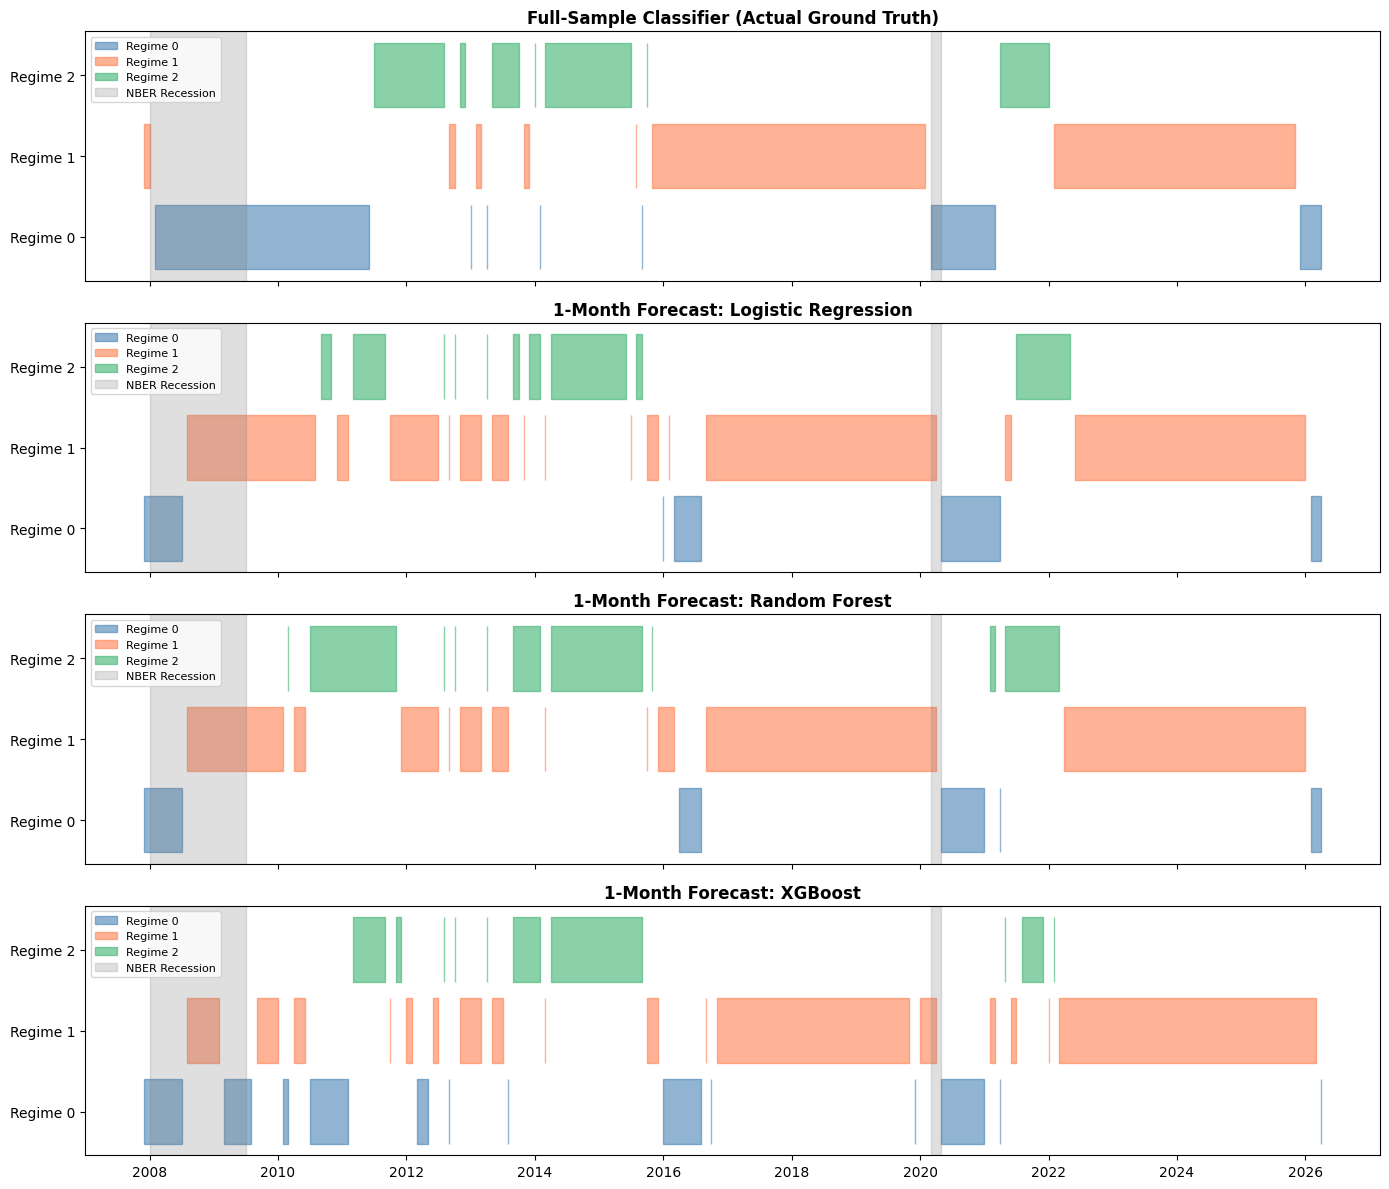

Plot saved.


In [27]:
# # Overlay all three forecasts against NBER recession dates
recession_eval = recession.reindex(eval_df.index).ffill().fillna(0)

# Upgraded to 4 subplots to view all challenger models
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

regime_colors = {0: 'steelblue', 1: 'coral', 2: 'mediumseagreen'}

columns_to_plot = ['actual_regimes', 'forecast_lr', 'forecast_rf', 'forecast_xgb']
titles = [
    'Full-Sample Classifier (Actual Ground Truth)',
    '1-Month Forecast: Logistic Regression',
    '1-Month Forecast: Random Forest',
    '1-Month Forecast: XGBoost'
]

for ax, col, title in zip(axes, columns_to_plot, titles):
    # It's possible some models missed predicting certain regimes, so we get unique from actual
    for label in sorted(eval_df['actual_regimes'].dropna().unique()):
        if label in eval_df[col].values:
            mask = eval_df[col] == label
            ax.fill_between(
                eval_df.index, label - 0.4, label + 0.4,
                where=mask,
                color=regime_colors.get(label, 'grey'),
                alpha=0.6,
                label=f'Regime {int(label)}'
            )

    # Shade NBER recessions
    in_recession = False
    for date, val in recession_eval['USREC'].items():
        if val == 1 and not in_recession:
            rec_start = date
            in_recession = True
        elif val == 0 and in_recession:
            ax.axvspan(rec_start, date, color='grey', alpha=0.25, label='NBER Recession')
            in_recession = False

    # Handle edge case if data ends while in a recession
    if in_recession:
        ax.axvspan(rec_start, eval_df.index[-1], color='grey', alpha=0.25, label='NBER Recession')

    ax.set_title(title, fontweight='bold')

    # Ensure y-ticks always show all 3 regimes even if a model missed one
    all_labels = sorted(eval_df['actual_regimes'].dropna().unique())
    ax.set_yticks(all_labels)
    ax.set_yticklabels([f'Regime {int(l)}' for l in all_labels])

    handles, labels_leg = ax.get_legend_handles_labels()
    by_label = dict(zip(labels_leg, handles))
    ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('forecast_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [28]:
# Save forecast output
forecast_df.to_csv('regime_forecasts.csv')
eval_df.to_csv('regime_forecast_evaluation.csv')
print('Saved: regime_forecasts.csv')
print('Saved: regime_forecast_evaluation.csv')
eval_df.tail(12)

Saved: regime_forecasts.csv
Saved: regime_forecast_evaluation.csv


,forecast_lr,forecast_rf,forecast_xgb,actual_regimes
2025-05-01,1,1,1,1
2025-06-01,1,1,1,1
2025-07-01,1,1,1,1
2025-08-01,1,1,1,1
2025-09-01,1,1,1,1
2025-10-01,1,1,1,1
2025-11-01,1,1,1,1
2025-12-01,1,1,1,0
2026-01-01,1,1,1,0
2026-02-01,0,0,1,0
